## 1. Basic utility functions

In [1]:
import json
import math
from pathlib import Path

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.ops import roi_align

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from tqdm.auto import tqdm

In [2]:
DATA_ROOT = "./bootplace_like_data"
CITYSCAPES_ROOT = "./data"

print("DATA_ROOT =", DATA_ROOT)
print("CITYSCAPES_ROOT =", CITYSCAPES_ROOT)

DATA_ROOT = ./bootplace_like_data
CITYSCAPES_ROOT = ./data


In [3]:
# Cityscapes labelIds
ROAD_LABEL_ID = 7
SIDEWALK_LABEL_ID = 8
PARKING_LABEL_ID = 9

PERSON_LABEL_IDS = {24, 25}                 # person, rider
VEHICLE_LABEL_IDS = {26, 27, 28, 31, 32, 33}  # car, truck, bus, train, motorcycle, bicycle

ALLOWED_CLASS_ID_TO_NAME = {
    24: "person",
    25: "rider",
    26: "car",
    27: "truck",
    28: "bus",
    31: "train",
    32: "motorcycle",
    33: "bicycle",
}

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

These helper functions read annotation files and label maps. They standardize how the notebook loads training metadata, semantic labels, and instance labels.

In [4]:
def read_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records


def load_label_map(path: Path):
    arr = np.array(Image.open(path))
    if arr.ndim != 2:
        raise ValueError(f"Expected single-channel label map, got shape {arr.shape} from {path}")
    return arr


def load_instance_map(path: Path):
    arr = np.array(Image.open(path))
    if arr.ndim != 2:
        raise ValueError(f"Expected single-channel instance map, got shape {arr.shape} from {path}")
    return arr

### 1.1 IoU meansurement

In [5]:
def normalize_box(box, w, h):
    x1, y1, x2, y2 = box
    return [x1 / w, y1 / h, x2 / w, y2 / h]


def box_area(boxes):
    return (boxes[..., 2] - boxes[..., 0]).clamp(min=0) * (boxes[..., 3] - boxes[..., 1]).clamp(min=0)


def pairwise_iou(boxes1, boxes2):
    """
    boxes1: [N, 4]
    boxes2: [M, 4]
    return: [N, M]
    """
    inter_x1 = torch.maximum(boxes1[:, None, 0], boxes2[None, :, 0])
    inter_y1 = torch.maximum(boxes1[:, None, 1], boxes2[None, :, 1])
    inter_x2 = torch.minimum(boxes1[:, None, 2], boxes2[None, :, 2])
    inter_y2 = torch.minimum(boxes1[:, None, 3], boxes2[None, :, 3])

    inter_w = (inter_x2 - inter_x1).clamp(min=0)
    inter_h = (inter_y2 - inter_y1).clamp(min=0)
    inter = inter_w * inter_h

    area1 = box_area(boxes1)[:, None]
    area2 = box_area(boxes2)[None, :]
    union = area1 + area2 - inter

    return inter / union.clamp(min=1e-6)


def aligned_box_iou(boxes1, boxes2):
    """
    boxes1: [B, 4]
    boxes2: [B, 4]
    return: [B]
    """
    inter_x1 = torch.maximum(boxes1[:, 0], boxes2[:, 0])
    inter_y1 = torch.maximum(boxes1[:, 1], boxes2[:, 1])
    inter_x2 = torch.minimum(boxes1[:, 2], boxes2[:, 2])
    inter_y2 = torch.minimum(boxes1[:, 3], boxes2[:, 3])

    inter_w = (inter_x2 - inter_x1).clamp(min=0)
    inter_h = (inter_y2 - inter_y1).clamp(min=0)
    inter = inter_w * inter_h

    area1 = (boxes1[:, 2] - boxes1[:, 0]).clamp(min=0) * (boxes1[:, 3] - boxes1[:, 1]).clamp(min=0)
    area2 = (boxes2[:, 2] - boxes2[:, 0]).clamp(min=0) * (boxes2[:, 3] - boxes2[:, 1]).clamp(min=0)
    union = area1 + area2 - inter

    return inter / union.clamp(min=1e-6)

### 1.2 Simple tokenizer  
We defined a light weight tokenizer that:
- splits prompts by spaces
- builds a small vocabulary from the training prompts
- pads or truncates each prompt to a fixed length  

We tried stronger text encoders earlier, but the final model improved more from geometric and semantic constraints than from more complex text modeling.

In [6]:
class SimplePromptTokenizer:
    def __init__(self, texts, max_len=8):
        self.pad_token = "<pad>"
        self.unk_token = "<unk>"
        self.max_len = max_len

        vocab = []
        for t in texts:
            vocab.extend(t.lower().strip().split())

        uniq = [self.pad_token, self.unk_token] + sorted(set(vocab))
        self.stoi = {w: i for i, w in enumerate(uniq)}
        self.itos = {i: w for w, i in self.stoi.items()}

    @property
    def vocab_size(self):
        return len(self.stoi)

    def encode(self, text):
        tokens = text.lower().strip().split()
        ids = [self.stoi.get(tok, self.stoi[self.unk_token]) for tok in tokens]
        ids = ids[: self.max_len]

        attn = [1] * len(ids)
        while len(ids) < self.max_len:
            ids.append(self.stoi[self.pad_token])
            attn.append(0)

        return torch.tensor(ids, dtype=torch.long), torch.tensor(attn, dtype=torch.long)

Initializes the prompt tokenizer and scene-class vocabulary from the training annotations.

In [7]:
def build_scene_class_vocab(train_ann_path):
    train_records = read_jsonl(train_ann_path)

    class_names = set()
    for r in train_records:
        class_names.add(r["target_class"])
        for s in r["scene_boxes_xyxy_abs"]:
            class_names.add(s["class_name"])

    class_names = sorted(class_names)

    stoi = {"<pad>": 0, "<unk>": 1}
    for c in class_names:
        stoi[c] = len(stoi)

    itos = {i: s for s, i in stoi.items()}
    return {"stoi": stoi, "itos": itos}


train_ann_path = Path(DATA_ROOT) / "train" / "annotations_train.jsonl"
val_ann_path = Path(DATA_ROOT) / "val" / "annotations_val.jsonl"

train_records = read_jsonl(train_ann_path)
val_records = read_jsonl(val_ann_path)

train_prompts = [r["prompt"] for r in train_records]
prompt_tokenizer = SimplePromptTokenizer(train_prompts, max_len=8)

scene_class_vocab = build_scene_class_vocab(train_ann_path)

print("num train records =", len(train_records))
print("num val records =", len(val_records))
print("prompt vocab size =", prompt_tokenizer.vocab_size)
print("scene class vocab =", scene_class_vocab["stoi"])

num train records = 8798
num val records = 980
prompt vocab size = 12
scene class vocab = {'<pad>': 0, '<unk>': 1, 'bicycle': 2, 'bus': 3, 'car': 4, 'motorcycle': 5, 'person': 6, 'rider': 7, 'train': 8, 'truck': 9}


In [8]:
def source_rel_to_label_path(cityscapes_root, source_image_rel):
    """
    source_image_rel example:
    leftImg8bit/train/aachen/aachen_000000_000019_leftImg8bit.png
    """
    p = Path(source_image_rel)
    split = p.parts[1]
    city = p.parts[2]
    filename = p.name
    stem = filename.replace("_leftImg8bit.png", "")
    label_path = Path(cityscapes_root) / "gtFine" / split / city / f"{stem}_gtFine_labelIds.png"
    return label_path


def source_rel_to_instance_path(cityscapes_root, source_image_rel):
    p = Path(source_image_rel)
    split = p.parts[1]
    city = p.parts[2]
    filename = p.name
    stem = filename.replace("_leftImg8bit.png", "")
    inst_path = Path(cityscapes_root) / "gtFine" / split / city / f"{stem}_gtFine_instanceIds.png"
    return inst_path

## 2. Candidate genration under support surface constraint  
Instead of allowing arbitrary bounding boxes, we:  
- define a support surface from scene semantics,  
- generate candidate boxes guided by that support surface,  
- compute semantic features for each candidate,  
- build a hard valid mask to remove implausible candidates.  

### 2.1 Support surface definition  
A street-scene object is not equally plausible everywhere.
The support surface gives the model a strong prior:
- persons should stand on walkable areas,
- cars should be placed on drivable areas,
- bicycles may appear in both road-adjacent and sidewalk-adjacent zones.  

This step reduces the candidate space before the ranking model even starts.  
So, we defined a support mask based on the prompt category.  
The support surface provides a semantic prior on where an object can plausibly be placed.

In [9]:
def get_support_mask(label_map, prompt):
    """
    label_map: H x W, Cityscapes labelIds
    prompt: e.g. 'place a person', 'place a car'
    """
    prompt = prompt.lower()

    if "person" in prompt or "rider" in prompt:
        support_mask = (label_map == SIDEWALK_LABEL_ID)

        if support_mask.sum() < 50:
            support_mask = (label_map == SIDEWALK_LABEL_ID) | (label_map == ROAD_LABEL_ID)

    elif "car" in prompt or "truck" in prompt or "bus" in prompt or "train" in prompt:
        support_mask = (label_map == ROAD_LABEL_ID) | (label_map == PARKING_LABEL_ID)

    elif "bicycle" in prompt or "motorcycle" in prompt:
        support_mask = (
            (label_map == ROAD_LABEL_ID) |
            (label_map == SIDEWALK_LABEL_ID) |
            (label_map == PARKING_LABEL_ID)
        )
    else:
        support_mask = (label_map == ROAD_LABEL_ID) | (label_map == SIDEWALK_LABEL_ID)

    return support_mask.astype(np.uint8)

### 2.2 Global fallback candidates  
Even though we want most candidates to come from the support surface, it is still useful to keep a very small amount of global coverage.  
Thus, we defines a small pool of generic fallback candidates that provide minimal global coverage outside the support surface. These are used only as backup candidates.

In [10]:
def generate_global_fallback_candidates(
    grid_size=5,
    scales=(0.10, 0.16, 0.24),
    aspect_ratios=(0.5, 1.0, 2.0),
):
    centers = torch.linspace(0.08, 0.92, steps=grid_size)
    boxes = []

    for cy in centers:
        for cx in centers:
            for s in scales:
                for ar in aspect_ratios:
                    w = s * math.sqrt(ar)
                    h = s / math.sqrt(ar)

                    x1 = max(0.0, float(cx - w / 2))
                    y1 = max(0.0, float(cy - h / 2))
                    x2 = min(1.0, float(cx + w / 2))
                    y2 = min(1.0, float(cy + h / 2))

                    if x2 > x1 and y2 > y1:
                        boxes.append([x1, y1, x2, y2])

    return torch.tensor(boxes, dtype=torch.float32)


GLOBAL_FALLBACK_CANDIDATES = generate_global_fallback_candidates()
print("num fallback candidates =", len(GLOBAL_FALLBACK_CANDIDATES))

num fallback candidates = 225


### 2.3 Class-specific shape priors  
Different object categories have very different bounding-box geometry.  
We defined category-specific box geometry priors so that different object types use different scales and aspect ratios to generate more plausible candidates.

In [11]:
def get_class_shape_priors(prompt):
    prompt = prompt.lower()

    if "person" in prompt or "rider" in prompt:
        scales = (0.10, 0.14, 0.18)
        aspect_ratios = (0.35, 0.45, 0.60)
    elif "car" in prompt or "truck" in prompt or "bus" in prompt or "train" in prompt:
        scales = (0.16, 0.22, 0.30)
        aspect_ratios = (1.2, 1.6, 2.0)
    elif "bicycle" in prompt or "motorcycle" in prompt:
        scales = (0.12, 0.16, 0.20)
        aspect_ratios = (0.8, 1.1, 1.5)
    else:
        scales = (0.12, 0.18, 0.24)
        aspect_ratios = (0.7, 1.0, 1.4)

    return scales, aspect_ratios

### 2.4 Support-surface-guided candidate generation  
This is our main idea and difference from original paper.  

We use bottom-center sampling because street-scene objects should be grounded on a support surface.
This is especially important for:
- people standing on sidewalks,
- cars resting on drivable regions.

Using bottom-center anchors better matches physical placement than center sampling

The general workflow of candidate generation:
1. gets the support mask,
2. sampels anchor points from that support mask,
3. uses those anchor points as bottom centers of candidate boxes,
4. builds candidate boxes using category-specific scales and aspect ratios,
5. adds a small number of global fallback candidates.

In [12]:
def sample_support_surface_candidates(
    label_map,
    prompt,
    num_total=256,
    support_ratio=0.95,
    seed=42,
):
    rng = np.random.default_rng(seed)
    H, W = label_map.shape

    support_mask = get_support_mask(label_map, prompt)
    ys, xs = np.where(support_mask > 0)

    scales, aspect_ratios = get_class_shape_priors(prompt)

    num_support = int(num_total * support_ratio)
    num_global = num_total - num_support

    boxes = []

    if len(xs) > 0 and num_support > 0:
        replace_flag = len(xs) < num_support
        sel = rng.choice(len(xs), size=num_support, replace=replace_flag)

        combo_list = [(s, ar) for s in scales for ar in aspect_ratios]

        for idx in sel:
            cx = (xs[idx] + 0.5) / W
            by = (ys[idx] + 0.5) / H

            s, ar = combo_list[rng.integers(0, len(combo_list))]
            bw = s * math.sqrt(ar)
            bh = s / math.sqrt(ar)

            x1 = float(cx - bw / 2)
            x2 = float(cx + bw / 2)
            y2 = float(by)
            y1 = float(by - bh)

            x1 = max(0.0, x1)
            y1 = max(0.0, y1)
            x2 = min(1.0, x2)
            y2 = min(1.0, y2)

            if x2 > x1 and y2 > y1:
                boxes.append([x1, y1, x2, y2])

    if num_global > 0:
        global_cands = GLOBAL_FALLBACK_CANDIDATES
        if len(global_cands) <= num_global:
            extra = global_cands
        else:
            perm = torch.randperm(len(global_cands))[:num_global]
            extra = global_cands[perm]
        boxes.extend(extra.tolist())

    while len(boxes) < num_total:
        extra = GLOBAL_FALLBACK_CANDIDATES[torch.randint(0, len(GLOBAL_FALLBACK_CANDIDATES), (1,))]
        boxes.extend(extra.tolist())

    boxes = torch.tensor(boxes[:num_total], dtype=torch.float32)
    return boxes, support_mask

### 2.5 Candidate semantic features  
For every candidate box, this function computes four semantic ratios:
- road ratio
- sidewalk ratio
- person ratio
- vehicle ratio

Each ratio measures how much of the candidate box overlaps that semantic category. These features help the ranking model reason about scene compatibility.

In [13]:
def resize_label_map_to_image_size(label_map, size_hw=(224, 224)):
    img = Image.fromarray(label_map.astype(np.uint8))
    img = img.resize((size_hw[1], size_hw[0]), resample=Image.NEAREST)
    return np.array(img)


def compute_candidate_semantic_features(label_map_resized, candidate_boxes):
    H, W = label_map_resized.shape
    feats = []

    road_mask = ((label_map_resized == ROAD_LABEL_ID) | (label_map_resized == PARKING_LABEL_ID)).astype(np.float32)
    sidewalk_mask = (label_map_resized == SIDEWALK_LABEL_ID).astype(np.float32)
    person_mask = np.isin(label_map_resized, list(PERSON_LABEL_IDS)).astype(np.float32)
    vehicle_mask = np.isin(label_map_resized, list(VEHICLE_LABEL_IDS)).astype(np.float32)

    for box in candidate_boxes:
        x1, y1, x2, y2 = box.tolist()
        ix1 = max(0, min(int(x1 * W), W - 1))
        iy1 = max(0, min(int(y1 * H), H - 1))
        ix2 = max(0, min(int(np.ceil(x2 * W)), W))
        iy2 = max(0, min(int(np.ceil(y2 * H)), H))

        if ix2 <= ix1:
            ix2 = min(W, ix1 + 1)
        if iy2 <= iy1:
            iy2 = min(H, iy1 + 1)

        road_ratio = float(road_mask[iy1:iy2, ix1:ix2].mean())
        sidewalk_ratio = float(sidewalk_mask[iy1:iy2, ix1:ix2].mean())
        person_ratio = float(person_mask[iy1:iy2, ix1:ix2].mean())
        vehicle_ratio = float(vehicle_mask[iy1:iy2, ix1:ix2].mean())

        feats.append([road_ratio, sidewalk_ratio, person_ratio, vehicle_ratio])

    return torch.tensor(feats, dtype=torch.float32)

### 2.6 Hard valid-mask construction  
This is one of the most important improvements compared with our previous version.  
It does not guarantee that the entire box lies on the support surface.
Instead, it provides a stronger approximation:
- the bottom-center should lie on the support surface,
- the bottom strip should overlap the support surface enough.  

For each candidate box, it checks whether the candidate is geometrically and semantically plausible.  
It uses:
- bottom-center location,
- bottom strip overlap with the support surface,
- class-specific semantic conditions.

Examples:
- a person candidate should not heavily overlap vehicle regions,
- a car candidate should not have high sidewalk ratio,
- a car candidate should have sufficient road overlap.

If a candidate fails the conditions, it becomes invalid and is later masked out during training and inference.

In [14]:
def build_candidate_valid_mask(label_map_resized, candidate_boxes, prompt):
    H, W = label_map_resized.shape

    support_mask = get_support_mask(label_map_resized, prompt).astype(np.uint8)

    sidewalk_mask = (label_map_resized == SIDEWALK_LABEL_ID).astype(np.float32)
    road_mask = ((label_map_resized == ROAD_LABEL_ID) | (label_map_resized == PARKING_LABEL_ID)).astype(np.float32)
    person_mask = np.isin(label_map_resized, list(PERSON_LABEL_IDS)).astype(np.float32)
    vehicle_mask = np.isin(label_map_resized, list(VEHICLE_LABEL_IDS)).astype(np.float32)

    valid = []

    for box in candidate_boxes:
        x1, y1, x2, y2 = box.tolist()

        ix1 = max(0, min(int(x1 * W), W - 1))
        iy1 = max(0, min(int(y1 * H), H - 1))
        ix2 = max(0, min(int(np.ceil(x2 * W)), W))
        iy2 = max(0, min(int(np.ceil(y2 * H)), H))

        if ix2 <= ix1:
            ix2 = min(W, ix1 + 1)
        if iy2 <= iy1:
            iy2 = min(H, iy1 + 1)

        # bottom center
        bcx = max(0, min(int(((x1 + x2) / 2) * W), W - 1))
        bcy = max(0, min(int(y2 * H) - 1, H - 1))

        bottom_center_on_support = 1.0 if support_mask[bcy, bcx] > 0 else 0.0

        # bottom strip
        box_h = max(1, iy2 - iy1)
        strip_h = max(2, int(box_h * 0.15))
        sy1 = max(0, iy2 - strip_h)
        sy2 = iy2

        bottom_strip_support_ratio = float(support_mask[sy1:sy2, ix1:ix2].mean()) if sy2 > sy1 else 0.0
        sidewalk_ratio = float(sidewalk_mask[iy1:iy2, ix1:ix2].mean())
        road_ratio = float(road_mask[iy1:iy2, ix1:ix2].mean())
        person_ratio = float(person_mask[iy1:iy2, ix1:ix2].mean())
        vehicle_ratio = float(vehicle_mask[iy1:iy2, ix1:ix2].mean())

        p = prompt.lower()

        if "person" in p or "rider" in p:
            ok = (
                bottom_center_on_support > 0.5 and
                bottom_strip_support_ratio >= 0.35 and
                vehicle_ratio <= 0.20
            )
        elif "car" in p or "truck" in p or "bus" in p or "train" in p:
            ok = (
                bottom_center_on_support > 0.5 and
                bottom_strip_support_ratio >= 0.45 and
                sidewalk_ratio <= 0.20 and
                person_ratio <= 0.10 and
                road_ratio >= 0.20
            )
        elif "bicycle" in p or "motorcycle" in p:
            ok = (
                bottom_center_on_support > 0.5 and
                bottom_strip_support_ratio >= 0.30
            )
        else:
            ok = (
                bottom_center_on_support > 0.5 and
                bottom_strip_support_ratio >= 0.30
            )

        valid.append(1.0 if ok else 0.0)

    valid = torch.tensor(valid, dtype=torch.float32)

    if valid.sum() == 0:
        fallback_scores = []
        support_mask = get_support_mask(label_map_resized, prompt).astype(np.uint8)

        for box in candidate_boxes:
            x1, y1, x2, y2 = box.tolist()
            ix1 = max(0, min(int(x1 * W), W - 1))
            iy1 = max(0, min(int(y1 * H), H - 1))
            ix2 = max(0, min(int(np.ceil(x2 * W)), W))
            iy2 = max(0, min(int(np.ceil(y2 * H)), H))

            if ix2 <= ix1:
                ix2 = min(W, ix1 + 1)
            if iy2 <= iy1:
                iy2 = min(H, iy1 + 1)

            box_h = max(1, iy2 - iy1)
            strip_h = max(2, int(box_h * 0.15))
            sy1 = max(0, iy2 - strip_h)
            sy2 = iy2

            score = float(support_mask[sy1:sy2, ix1:ix2].mean()) if sy2 > sy1 else 0.0
            fallback_scores.append(score)

        best_idx = int(np.argmax(fallback_scores))
        valid[best_idx] = 1.0

    return valid

In [15]:
sample_rec = train_records[0]
print("sample prompt =", sample_rec["prompt"])
print("sample source image rel =", sample_rec["source_image_rel"])

label_path = source_rel_to_label_path(CITYSCAPES_ROOT, sample_rec["source_image_rel"])
label_map = load_label_map(label_path)

cand_boxes, support_mask = sample_support_surface_candidates(
    label_map=label_map,
    prompt=sample_rec["prompt"],
    num_total=32,
    support_ratio=0.95,
    seed=42,
)

label_map_resized = resize_label_map_to_image_size(label_map, size_hw=(224, 224))
cand_sem = compute_candidate_semantic_features(label_map_resized, cand_boxes)
cand_valid = build_candidate_valid_mask(label_map_resized, cand_boxes, sample_rec["prompt"])

print("label_map shape =", label_map.shape)
print("cand_boxes shape =", tuple(cand_boxes.shape))
print("cand_sem shape =", tuple(cand_sem.shape))
print("cand_valid shape =", tuple(cand_valid.shape))
print("num valid candidates =", int(cand_valid.sum().item()))
print("first 5 valid mask =", cand_valid[:5])

sample prompt = place a bicycle
sample source image rel = leftImg8bit\train\aachen\aachen_000000_000019_leftImg8bit.png
label_map shape = (1024, 2048)
cand_boxes shape = (32, 4)
cand_sem shape = (32, 4)
cand_valid shape = (32,)
num valid candidates = 31
first 5 valid mask = tensor([1., 1., 1., 1., 1.])


## 3. Dataset construction and batching

### 3.1 Dataset class  
This dataset class prepares the full training sample used by the final model. Each sample includes the image, prompt, scene context, support-surface-guided candidate boxes, semantic candidate features, a hard valid mask, and IoU-based candidate supervision.  
**Best candidate constraints:**  
A very important detail in the final dataset is that the “best” candidate is not chosen from all candidates.  
Instead:
- we first compute IoU between each candidate and the target box,
- then we invalidate all candidates that fail the hard constraints,
- then we choose the best candidate only among the remaining valid ones.  

This makes training consistent with the final placement logic.  
Without this step, the supervision could favor:
- a candidate that overlaps well with the target in 2D,
- but violates the support surface,
- or produces an implausible placement.

So this design ensures that the model learns to rank plausible candidates, not just geometrically similar ones.

In [16]:
class BootplaceSupportSurfaceDataset(Dataset):
    def __init__(
        self,
        data_root,
        cityscapes_root,
        split="train",
        tokenizer=None,
        scene_class_vocab=None,
        image_size=224,
        num_candidates=256,
        support_ratio=0.95,
        base_seed=42,
    ):
        self.data_root = Path(data_root)
        self.cityscapes_root = Path(cityscapes_root)
        self.split = split
        self.records = read_jsonl(self.data_root / split / f"annotations_{split}.jsonl")
        self.tokenizer = tokenizer
        self.scene_class_vocab = scene_class_vocab
        self.image_size = image_size
        self.num_candidates = num_candidates
        self.support_ratio = support_ratio
        self.base_seed = base_seed

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
        ])

    def __len__(self):
        return len(self.records)

    def _normalize_box_tensor(self, box, w, h):
        x1, y1, x2, y2 = box
        return torch.tensor([x1 / w, y1 / h, x2 / w, y2 / h], dtype=torch.float32)

    def __getitem__(self, idx):
        rec = self.records[idx]

        # 1. image
        bg_path = self.data_root / rec["background_rel"]
        image = Image.open(bg_path).convert("RGB")
        image_tensor = self.transform(image)

        # 2. image size
        w, h = rec["image_size_wh"]

        # 3. target bbox
        target_bbox = self._normalize_box_tensor(rec["target_bbox_xyxy_abs"], w, h)

        # 4. prompt
        prompt = rec["prompt"]
        input_ids, attention_mask = self.tokenizer.encode(prompt)

        # 5. scene boxes + scene class ids
        scene_boxes = []
        scene_class_ids = []

        for item in rec["scene_boxes_xyxy_abs"]:
            scene_boxes.append(self._normalize_box_tensor(item["bbox_xyxy_abs"], w, h))
            cls_id = self.scene_class_vocab["stoi"].get(
                item["class_name"],
                self.scene_class_vocab["stoi"]["<unk>"]
            )
            scene_class_ids.append(cls_id)

        if len(scene_boxes) == 0:
            scene_boxes = torch.zeros((0, 4), dtype=torch.float32)
            scene_class_ids = torch.zeros((0,), dtype=torch.long)
        else:
            scene_boxes = torch.stack(scene_boxes, dim=0)
            scene_class_ids = torch.tensor(scene_class_ids, dtype=torch.long)

        # 6. label map
        label_path = source_rel_to_label_path(self.cityscapes_root, rec["source_image_rel"])
        label_map = load_label_map(label_path)

        # 7. support-surface candidates
        candidate_boxes, support_mask = sample_support_surface_candidates(
            label_map=label_map,
            prompt=prompt,
            num_total=self.num_candidates,
            support_ratio=self.support_ratio,
            seed=self.base_seed + idx,
        )

        # 8. resized label map for semantic feature + valid mask
        label_map_resized = resize_label_map_to_image_size(
            label_map,
            size_hw=(self.image_size, self.image_size)
        )

        candidate_sem_feats = compute_candidate_semantic_features(
            label_map_resized,
            candidate_boxes
        )

        candidate_valid_mask = build_candidate_valid_mask(
            label_map_resized=label_map_resized,
            candidate_boxes=candidate_boxes,
            prompt=prompt,
        )

        # 9. IoU supervision
        candidate_ious = pairwise_iou(candidate_boxes, target_bbox.unsqueeze(0)).squeeze(1)

        valid_ious = candidate_ious.clone()
        valid_ious[candidate_valid_mask < 0.5] = -1.0
        best_candidate_idx = torch.argmax(valid_ious)

        return {
            "image": image_tensor,
            "prompt": prompt,
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "target_bbox": target_bbox,
            "scene_boxes": scene_boxes,
            "scene_class_ids": scene_class_ids,
            "candidate_boxes": candidate_boxes,
            "candidate_sem_feats": candidate_sem_feats,
            "candidate_valid_mask": candidate_valid_mask,
            "candidate_ious": candidate_ious,
            "best_candidate_idx": best_candidate_idx,
            "target_class": rec["target_class"],
            "background_rel": rec["background_rel"],
        }

### 3.2 Finalize dataset batching and dataloader construction  

In [17]:
def support_surface_collate_fn(batch):
    images = torch.stack([x["image"] for x in batch], dim=0)
    input_ids = torch.stack([x["input_ids"] for x in batch], dim=0)
    attention_mask = torch.stack([x["attention_mask"] for x in batch], dim=0)
    target_bboxes = torch.stack([x["target_bbox"] for x in batch], dim=0)

    candidate_boxes = torch.stack([x["candidate_boxes"] for x in batch], dim=0)           # [B, K, 4]
    candidate_sem_feats = torch.stack([x["candidate_sem_feats"] for x in batch], dim=0)   # [B, K, 4]
    candidate_valid_mask = torch.stack([x["candidate_valid_mask"] for x in batch], dim=0) # [B, K]
    candidate_ious = torch.stack([x["candidate_ious"] for x in batch], dim=0)             # [B, K]
    best_candidate_idx = torch.stack([x["best_candidate_idx"] for x in batch], dim=0)     # [B]

    max_num_scene = max(x["scene_boxes"].shape[0] for x in batch)

    padded_scene_boxes = []
    padded_scene_class_ids = []
    scene_box_masks = []

    for x in batch:
        n = x["scene_boxes"].shape[0]

        if n < max_num_scene:
            pad_boxes = torch.zeros((max_num_scene - n, 4), dtype=torch.float32)
            boxes = torch.cat([x["scene_boxes"], pad_boxes], dim=0)

            pad_cls = torch.zeros((max_num_scene - n,), dtype=torch.long)
            cls_ids = torch.cat([x["scene_class_ids"], pad_cls], dim=0)

            mask = torch.cat([
                torch.ones(n, dtype=torch.float32),
                torch.zeros(max_num_scene - n, dtype=torch.float32)
            ], dim=0)
        else:
            boxes = x["scene_boxes"]
            cls_ids = x["scene_class_ids"]
            mask = torch.ones(n, dtype=torch.float32)

        padded_scene_boxes.append(boxes)
        padded_scene_class_ids.append(cls_ids)
        scene_box_masks.append(mask)

    padded_scene_boxes = torch.stack(padded_scene_boxes, dim=0)
    padded_scene_class_ids = torch.stack(padded_scene_class_ids, dim=0)
    scene_box_masks = torch.stack(scene_box_masks, dim=0)

    return {
        "images": images,
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "target_bboxes": target_bboxes,
        "scene_boxes": padded_scene_boxes,
        "scene_class_ids": padded_scene_class_ids,
        "scene_box_masks": scene_box_masks,
        "candidate_boxes": candidate_boxes,
        "candidate_sem_feats": candidate_sem_feats,
        "candidate_valid_mask": candidate_valid_mask,
        "candidate_ious": candidate_ious,
        "best_candidate_idx": best_candidate_idx,
        "prompts": [x["prompt"] for x in batch],
        "target_classes": [x["target_class"] for x in batch],
        "background_rels": [x["background_rel"] for x in batch],
    }

In [57]:
train_dataset_ss = BootplaceSupportSurfaceDataset(
    data_root=DATA_ROOT,
    cityscapes_root=CITYSCAPES_ROOT,
    split="train",
    tokenizer=prompt_tokenizer,
    scene_class_vocab=scene_class_vocab,
    image_size=224,
    num_candidates=256,
    support_ratio=0.95,
    base_seed=42,
)

val_dataset_ss = BootplaceSupportSurfaceDataset(
    data_root=DATA_ROOT,
    cityscapes_root=CITYSCAPES_ROOT,
    split="val",
    tokenizer=prompt_tokenizer,
    scene_class_vocab=scene_class_vocab,
    image_size=224,
    num_candidates=256,
    support_ratio=0.95,
    base_seed=4242,
)

train_loader_ss = DataLoader(
    train_dataset_ss,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=support_surface_collate_fn,
)

val_loader_ss = DataLoader(
    val_dataset_ss,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    collate_fn=support_surface_collate_fn,
)

print("train size =", len(train_dataset_ss))
print("val size =", len(val_dataset_ss))

train size = 8798
val size = 980


In [19]:
batch_ss = next(iter(train_loader_ss))

for k, v in batch_ss.items():
    if torch.is_tensor(v):
        print(k, tuple(v.shape), v.dtype)
    else:
        print(k, type(v), len(v))

images (16, 3, 224, 224) torch.float32
input_ids (16, 8) torch.int64
attention_mask (16, 8) torch.int64
target_bboxes (16, 4) torch.float32
scene_boxes (16, 46, 4) torch.float32
scene_class_ids (16, 46) torch.int64
scene_box_masks (16, 46) torch.float32
candidate_boxes (16, 256, 4) torch.float32
candidate_sem_feats (16, 256, 4) torch.float32
candidate_valid_mask (16, 256) torch.float32
candidate_ious (16, 256) torch.float32
best_candidate_idx (16,) torch.int64
prompts <class 'list'> 16
target_classes <class 'list'> 16
background_rels <class 'list'> 16


## 4. Model architecture

### 4.1 General idea  
This model combines five types of information:  
1. **Global image feature**: What the overall scene looks like
2. **Text feature**: What object the prompt asks us to place
3. **Scene-context feature**: What objects already exist in the scene
4. **Candidate visual and geometric feature**: What each candidate box looks like and where it is
5. **Candidate semantic feature**: What semantic region each candidate covers, such as road or sidewalk  

The placement decision depends on multiple factors, like the traget object in the prompt, the surrounding sscene objects, the semantical information and so on. A sigle direction-regression head would have trouble modeling these alternatives clearly. Thus, this deigsn of candidating raking is more natureal for this task.

### 4.2 Model definition  
We defined a ranking neural netwrok, it includes:
- an image encoder
- a text encoder
- a scene-context encoder
- a candidate box encoder
- a semantic feature encoder
- a score head  

It outputs:
- a score for each candidate
- the best candidate index
- the predicted bounding box

Each component solves a different sub-problem:
- image encoder: scene appearance
- text encoder: target object identity
- scene encoder: context from existing objects
- candidate encoder: local visual evidence and box geometry
- semantic encoder: region-type information
- score head: final candidate ranking

The image encoder is frozen in the final version to keep training stable and efficient. The ranking performance is mainly improved through candidate design and constraint modeling rather than by fully finetuning the backbone.


In [20]:
class BootplaceSupportSurfaceScoringModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_scene_classes,
        text_embed_dim=128,
        hidden_dim=256,
        scene_dim=128,
        scene_class_embed_dim=32,
        sem_feat_dim=4,
        freeze_image_encoder=True,
    ):
        super().__init__()
        self.freeze_image_encoder = freeze_image_encoder

        try:
            from torchvision.models import resnet18, ResNet18_Weights
            backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        except Exception:
            from torchvision.models import resnet18
            backbone = resnet18(pretrained=True)

        # image encoder
        self.image_encoder = nn.Sequential(*list(backbone.children())[:-2])   # [B, 512, 7, 7]
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.image_feat_dim = 512

        if freeze_image_encoder:
            for p in self.image_encoder.parameters():
                p.requires_grad = False

        self.image_proj = nn.Sequential(
            nn.Linear(self.image_feat_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
        )

        # text encoder
        self.text_embedding = nn.Embedding(vocab_size, text_embed_dim, padding_idx=0)
        self.text_proj = nn.Sequential(
            nn.Linear(text_embed_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
        )

        # scene encoder
        self.scene_box_encoder = nn.Sequential(
            nn.Linear(4, scene_dim),
            nn.ReLU(inplace=True),
            nn.Linear(scene_dim, scene_dim),
            nn.ReLU(inplace=True),
        )

        self.scene_class_embedding = nn.Embedding(
            num_scene_classes,
            scene_class_embed_dim,
            padding_idx=0,
        )

        self.scene_fuse = nn.Sequential(
            nn.Linear(scene_dim + scene_class_embed_dim, scene_dim),
            nn.ReLU(inplace=True),
            nn.Linear(scene_dim, scene_dim),
            nn.ReLU(inplace=True),
        )

        self.scene_proj = nn.Sequential(
            nn.Linear(scene_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
        )

        # candidate visual + box encoder
        self.candidate_box_encoder = nn.Sequential(
            nn.Linear(4, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
        )

        self.roi_proj = nn.Sequential(
            nn.Linear(self.image_feat_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
        )

        self.candidate_fuse = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
        )

        # semantic feature encoder
        self.semantic_encoder = nn.Sequential(
            nn.Linear(sem_feat_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
        )

        # query = global image + text + scene
        self.query_proj = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
        )

        # score head
        self.score_head = nn.Sequential(
            nn.Linear(hidden_dim * 5, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, 1),
        )

    def train(self, mode=True):
        super().train(mode)
        if self.freeze_image_encoder:
            self.image_encoder.eval()
        return self

    def encode_image(self, images):
        fmap = self.image_encoder(images)                   # [B, 512, 7, 7]
        pooled = self.global_pool(fmap).flatten(1)         # [B, 512]
        global_feat = self.image_proj(pooled)              # [B, H]
        return fmap, global_feat

    def encode_text(self, input_ids, attention_mask):
        emb = self.text_embedding(input_ids)               # [B, L, D]
        mask = attention_mask.unsqueeze(-1).float()        # [B, L, 1]

        summed = (emb * mask).sum(dim=1)
        denom = mask.sum(dim=1).clamp(min=1.0)
        pooled = summed / denom

        txt_feat = self.text_proj(pooled)                  # [B, H]
        return txt_feat

    def encode_scene(self, scene_boxes, scene_class_ids, scene_box_masks):
        if scene_boxes.shape[1] == 0:
            B = scene_boxes.shape[0]
            device = scene_boxes.device
            hidden_dim = self.scene_proj[0].out_features
            return torch.zeros((B, hidden_dim), device=device)

        box_feat = self.scene_box_encoder(scene_boxes)         # [B, M, scene_dim]
        cls_feat = self.scene_class_embedding(scene_class_ids) # [B, M, cls_dim]

        obj_feat = torch.cat([box_feat, cls_feat], dim=-1)
        obj_feat = self.scene_fuse(obj_feat)                   # [B, M, scene_dim]

        mask = scene_box_masks.unsqueeze(-1).float()
        summed = (obj_feat * mask).sum(dim=1)
        denom = mask.sum(dim=1).clamp(min=1.0)
        pooled = summed / denom

        scn_feat = self.scene_proj(pooled)                     # [B, H]
        return scn_feat

    def _build_rois(self, candidate_boxes, image_h, image_w, device):
        B, K, _ = candidate_boxes.shape

        boxes_px = candidate_boxes.clone()
        boxes_px[..., 0] *= image_w
        boxes_px[..., 2] *= image_w
        boxes_px[..., 1] *= image_h
        boxes_px[..., 3] *= image_h

        batch_ids = torch.arange(B, device=device).view(B, 1, 1).expand(B, K, 1).float()
        rois = torch.cat([batch_ids, boxes_px], dim=-1).reshape(B * K, 5)
        return rois

    def encode_candidates(self, fmap, candidate_boxes, image_h, image_w):
        B, K, _ = candidate_boxes.shape
        device = candidate_boxes.device

        rois = self._build_rois(candidate_boxes, image_h, image_w, device)

        spatial_scale = fmap.shape[-1] / float(image_w)
        roi_feat = roi_align(
            fmap,
            rois,
            output_size=(1, 1),
            spatial_scale=spatial_scale,
            aligned=True,
        )                                                     # [B*K, 512, 1, 1]

        roi_feat = roi_feat.flatten(1)                        # [B*K, 512]
        roi_feat = self.roi_proj(roi_feat)                    # [B*K, H]
        roi_feat = roi_feat.view(B, K, -1)                    # [B, K, H]

        box_feat = self.candidate_box_encoder(candidate_boxes.view(B * K, 4))
        box_feat = box_feat.view(B, K, -1)                    # [B, K, H]

        cand_feat = torch.cat([roi_feat, box_feat], dim=-1)
        cand_feat = self.candidate_fuse(cand_feat)            # [B, K, H]
        return cand_feat

    def encode_candidate_semantics(self, candidate_sem_feats):
        B, K, D = candidate_sem_feats.shape
        sem_feat = self.semantic_encoder(candidate_sem_feats.view(B * K, D))
        sem_feat = sem_feat.view(B, K, -1)                    # [B, K, H]
        return sem_feat

    def forward(
        self,
        images,
        input_ids,
        attention_mask,
        scene_boxes,
        scene_class_ids,
        scene_box_masks,
        candidate_boxes,
        candidate_sem_feats,
    ):
        B, _, H, W = images.shape

        fmap, global_feat = self.encode_image(images)
        txt_feat = self.encode_text(input_ids, attention_mask)
        scn_feat = self.encode_scene(scene_boxes, scene_class_ids, scene_box_masks)

        query_feat = self.query_proj(torch.cat([global_feat, txt_feat, scn_feat], dim=-1))  # [B, H]
        cand_feat = self.encode_candidates(fmap, candidate_boxes, H, W)                      # [B, K, H]
        sem_feat = self.encode_candidate_semantics(candidate_sem_feats)                       # [B, K, H]

        K = candidate_boxes.shape[1]
        query_expand = query_feat.unsqueeze(1).expand(B, K, -1)

        score_in = torch.cat([
            cand_feat,
            sem_feat,
            query_expand,
            cand_feat * query_expand,
            sem_feat * query_expand,
        ], dim=-1)                                                                           # [B, K, 5H]

        scores = self.score_head(score_in).squeeze(-1)                                       # [B, K]
        best_idx = torch.argmax(scores, dim=1)
        pred_boxes = candidate_boxes[torch.arange(B, device=images.device), best_idx]

        return {
            "scores": scores,
            "best_idx": best_idx,
            "pred_boxes": pred_boxes,
        }

## 5. Training objective, optimization, and training loop  
The final model is trained as a candidate-ranking system rather than a direct box regressor. This is more suitable for object placement, since multiple candidate locations may be plausible in the same scene.

### 5.1 Soft target construction  
We use the IoU between each candidate and the ground-truth box (only among valid candidates). Higher IoU candidates reveive larger weights.  
The object placement task is multi-modal. Thus, we don't say only one candidate is correct, we pick top1 and topk as the evaluation metrics for the ranking system.
- Top1 tells us how good the best prediction is.
- Top5 tells us whether the candidate ranking contains a good option near the top.  

The **loss function** is built based on **soft ranking loss** and **hard classification loss**: $L=\lambda_1L_{soft}+\lambda_2L_{hard}$  
**Hard classification loss**: Among all valid candidates, there is one candidate that should be treated as the main target. So it chose the candidate that is the best one (highest IoU).  
**soft ranking loss**: We do not assume only one candidate is acceptable. Some other valid candidates may also be reasonable. Thus, we build a soft target distribution from IoU values.

In [21]:
def build_soft_targets(candidate_ious, best_candidate_idx, candidate_valid_mask, gamma=2.0):
    B, K = candidate_ious.shape
    soft_targets = []

    for b in range(B):
        ious = candidate_ious[b].clamp(min=0) * candidate_valid_mask[b]
        weights = ious ** gamma
        s = weights.sum()

        if float(s) < 1e-8:
            target = torch.zeros_like(weights)
            target[best_candidate_idx[b]] = 1.0
        else:
            target = weights / s

        soft_targets.append(target)

    return torch.stack(soft_targets, dim=0)


def topk_iou_from_scores(scores, candidate_ious, k=1):
    topk_idx = torch.topk(scores, k=k, dim=1).indices
    gathered = torch.gather(candidate_ious, dim=1, index=topk_idx)
    return gathered.max(dim=1).values


def compute_candidate_scoring_loss(
    scores,
    candidate_ious,
    best_candidate_idx,
    candidate_valid_mask,
    soft_weight=1.0,
    hard_weight=0.5,
    gamma=2.0,
):
    log_probs = F.log_softmax(scores, dim=1)

    soft_targets = build_soft_targets(
        candidate_ious=candidate_ious,
        best_candidate_idx=best_candidate_idx,
        candidate_valid_mask=candidate_valid_mask,
        gamma=gamma,
    )

    loss_soft = -(soft_targets * log_probs).sum(dim=1).mean()
    loss_hard = F.cross_entropy(scores, best_candidate_idx)

    total = soft_weight * loss_soft + hard_weight * loss_hard

    top1_iou = topk_iou_from_scores(scores, candidate_ious, k=1).mean()
    top5_iou = topk_iou_from_scores(scores, candidate_ious, k=5).mean()

    return total, {
        "loss_total": float(total.detach().cpu()),
        "loss_soft": float(loss_soft.detach().cpu()),
        "loss_hard": float(loss_hard.detach().cpu()),
        "top1_iou": float(top1_iou.detach().cpu()),
        "top5_iou": float(top5_iou.detach().cpu()),
    }

### 5.2 Training design
**Why we masked invalid candidates during training?**  
This is one of the most important details of our design. Even if the model predicts scores for all candidates, invalid candidates must not compete with valid ones. Because this ensures that the model learns to rank only geometrically and semantically plausible candidates.  
The `run_one_epoch_support_surface()` function runs one epoch over a dataloader.
It works in both modes:
- training mode if an optimizer is given,
- validation mode otherwise.

For each batch, it:
1.	moves all tensors to the device,
2.	runs the model forward pass,
3.	masks invalid candidates,
4.	computes loss and metrics,
5.	performs backpropagation if training,
6.	accumulates epoch-level statistics.  

In [22]:
def run_one_epoch_support_surface(model, loader, optimizer=None, device="cuda"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    loss_total_sum = 0.0
    loss_soft_sum = 0.0
    loss_hard_sum = 0.0
    top1_iou_sum = 0.0
    top5_iou_sum = 0.0
    num_batches = 0

    desc = "train" if is_train else "val"
    pbar = tqdm(loader, desc=desc, leave=False)

    for batch in pbar:
        images = batch["images"].to(device, non_blocking=True)
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        scene_boxes = batch["scene_boxes"].to(device, non_blocking=True)
        scene_class_ids = batch["scene_class_ids"].to(device, non_blocking=True)
        scene_box_masks = batch["scene_box_masks"].to(device, non_blocking=True)
        candidate_boxes = batch["candidate_boxes"].to(device, non_blocking=True)
        candidate_sem_feats = batch["candidate_sem_feats"].to(device, non_blocking=True)
        candidate_valid_mask = batch["candidate_valid_mask"].to(device, non_blocking=True)
        candidate_ious = batch["candidate_ious"].to(device, non_blocking=True)
        best_candidate_idx = batch["best_candidate_idx"].to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            out = model(
                images=images,
                input_ids=input_ids,
                attention_mask=attention_mask,
                scene_boxes=scene_boxes,
                scene_class_ids=scene_class_ids,
                scene_box_masks=scene_box_masks,
                candidate_boxes=candidate_boxes,
                candidate_sem_feats=candidate_sem_feats,
            )

            scores = out["scores"]

            if torch.isnan(scores).any() or torch.isinf(scores).any():
                print("Found non-finite scores, skip batch")
                continue

            scores = scores.masked_fill(candidate_valid_mask < 0.5, -1e4)

            loss, stats = compute_candidate_scoring_loss(
                scores=scores,
                candidate_ious=candidate_ious,
                best_candidate_idx=best_candidate_idx,
                candidate_valid_mask=candidate_valid_mask,
                soft_weight=1.0,
                hard_weight=0.5,
                gamma=2.0,
            )

            if not torch.isfinite(loss):
                print("Found non-finite loss, skip batch")
                continue

            if is_train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        loss_total_sum += stats["loss_total"]
        loss_soft_sum += stats["loss_soft"]
        loss_hard_sum += stats["loss_hard"]
        top1_iou_sum += stats["top1_iou"]
        top5_iou_sum += stats["top5_iou"]
        num_batches += 1

        pbar.set_postfix({
            "loss": f"{loss_total_sum / num_batches:.4f}",
            "top1": f"{top1_iou_sum / num_batches:.4f}",
            "top5": f"{top5_iou_sum / num_batches:.4f}",
        })

    return {
        "loss_total": loss_total_sum / max(1, num_batches),
        "loss_soft": loss_soft_sum / max(1, num_batches),
        "loss_hard": loss_hard_sum / max(1, num_batches),
        "top1_iou": top1_iou_sum / max(1, num_batches),
        "top5_iou": top5_iou_sum / max(1, num_batches),
    }

### 5.3 Instantiate a model
#### Optimizer  
We choose AdamW as the optimizer because it's a stable and standatad choice for this kind of ranking model.  
The learning rate is intentionally conservative because the backbone is forzen, the dataset is not huge and the model already relies on strong priors from candidate design.

In [55]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
model_ss = BootplaceSupportSurfaceScoringModel(
    vocab_size=prompt_tokenizer.vocab_size,
    num_scene_classes=len(scene_class_vocab["stoi"]),
    text_embed_dim=128,
    hidden_dim=256,
    scene_dim=128,
    scene_class_embed_dim=32,
    sem_feat_dim=4,
    freeze_image_encoder=True,
).to(device)

optimizer_ss = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_ss.parameters()),
    lr=1e-4,
    weight_decay=1e-4,
)

num_params = sum(p.numel() for p in model_ss.parameters() if p.requires_grad)
print("device =", device)
print("trainable params =", num_params)

device = cuda
trainable params = 1306945


### 5.4 Training loop  
Our training workflow for each epoch:  
1. runs training,
2. runs validation,
3. records metrics,
4. saves the latest checkpoint,
5. saves the best checkpoint if validation improves.

In [ ]:
from pathlib import Path
import torch

ckpt_dir_ss = Path("./checkpoints")
ckpt_dir_ss.mkdir(parents=True, exist_ok=True)

last_ckpt = ckpt_dir_ss / "03_ss_hard_last.pt"
best_ckpt = ckpt_dir_ss / "03_ss_hard_best.pt"

# old_best_ckpt = Path("./checkpoints") / "no02_supportsurface_best.pt"

num_epochs = 5

if last_ckpt.exists():
    ckpt_ss = torch.load(last_ckpt, map_location=device)

    model_ss.load_state_dict(ckpt_ss["model_state_dict"])
    optimizer_ss.load_state_dict(ckpt_ss["optimizer_state_dict"])

    start_epoch = ckpt_ss.get("epoch", 0)
    history_ss = ckpt_ss.get("history", [])
    best_val_top1_iou_ss = ckpt_ss.get("best_val_top1_iou", -1.0)

    print(f"loaded checkpoint from: {last_ckpt}")
    print("start_epoch =", start_epoch)
    print("history len =", len(history_ss))
    print("best_val_top1_iou =", best_val_top1_iou_ss)

else:
    print("no new hard-constraint checkpoint found")

    start_epoch = 0
    history_ss = []
    best_val_top1_iou_ss = -1.0

    if old_best_ckpt.exists():
        warm_ckpt = torch.load(old_best_ckpt, map_location=device)

        current_state = model_ss.state_dict()
        loadable_state = {}

        for k, v in warm_ckpt["model_state_dict"].items():
            if k in current_state and current_state[k].shape == v.shape:
                loadable_state[k] = v

        missing_keys, unexpected_keys = model_ss.load_state_dict(loadable_state, strict=False)

        print(f"warm-started from old checkpoint: {old_best_ckpt}")
        print("num loaded keys =", len(loadable_state))
        print("num missing keys =", len(missing_keys))
        print("num unexpected keys =", len(unexpected_keys))
    else:
        print("no old checkpoint found, training from scratch")

for epoch in range(start_epoch + 1, start_epoch + num_epochs + 1):
    train_stats_ss = run_one_epoch_support_surface(
        model=model_ss,
        loader=train_loader_ss,
        optimizer=optimizer_ss,
        device=device,
    )

    val_stats_ss = run_one_epoch_support_surface(
        model=model_ss,
        loader=val_loader_ss,
        optimizer=None,
        device=device,
    )

    log = {
        "epoch": epoch,
        "train": train_stats_ss,
        "val": val_stats_ss,
    }
    history_ss.append(log)

    print(f"Epoch {epoch}/{start_epoch + num_epochs}")
    print(
        f"  train | total={train_stats_ss['loss_total']:.4f} "
        f"soft={train_stats_ss['loss_soft']:.4f} "
        f"hard={train_stats_ss['loss_hard']:.4f} "
        f"top1_iou={train_stats_ss['top1_iou']:.4f} "
        f"top5_iou={train_stats_ss['top5_iou']:.4f}"
    )
    print(
        f"  val   | total={val_stats_ss['loss_total']:.4f} "
        f"soft={val_stats_ss['loss_soft']:.4f} "
        f"hard={val_stats_ss['loss_hard']:.4f} "
        f"top1_iou={val_stats_ss['top1_iou']:.4f} "
        f"top5_iou={val_stats_ss['top5_iou']:.4f}"
    )

    is_new_best = val_stats_ss["top1_iou"] > best_val_top1_iou_ss
    if is_new_best:
        best_val_top1_iou_ss = val_stats_ss["top1_iou"]

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model_ss.state_dict(),
                "optimizer_state_dict": optimizer_ss.state_dict(),
                "history": history_ss,
                "best_val_top1_iou": best_val_top1_iou_ss,
            },
            best_ckpt
        )
        print(f"  saved new best checkpoint, best_val_top1_iou = {best_val_top1_iou_ss:.4f}")

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model_ss.state_dict(),
            "optimizer_state_dict": optimizer_ss.state_dict(),
            "history": history_ss,
            "best_val_top1_iou": best_val_top1_iou_ss,
        },
        last_ckpt
    )

print("training finished")
print("best_val_top1_iou =", best_val_top1_iou_ss)

In [ ]:
import torch

ckpt = torch.load("./checkpoints/03_ss_hard_last.pt", map_location="cpu")

print(ckpt.keys())
history = ckpt["history"]

for item in history:
    epoch = item["epoch"]
    train = item["train"]
    val = item["val"]

    print(f"Epoch {epoch}")
    print(
        f"  train | total={train['loss_total']:.4f} "
        f"soft={train['loss_soft']:.4f} "
        f"hard={train['loss_hard']:.4f} "
        f"top1={train['top1_iou']:.4f} "
        f"top5={train['top5_iou']:.4f}"
    )
    print(
        f"  val   | total={val['loss_total']:.4f} "
        f"soft={val['loss_soft']:.4f} "
        f"hard={val['loss_hard']:.4f} "
        f"top1={val['top1_iou']:.4f} "
        f"top5={val['top5_iou']:.4f}"
    )

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'history', 'best_val_top1_iou'])
Epoch 1
  train | total=5.8891 soft=4.0588 hard=3.6606 top1=0.0576 top5=0.0985
  val   | total=5.6290 soft=3.9230 hard=3.4120 top1=0.0570 top5=0.0966
Epoch 2
  train | total=5.5299 soft=3.8721 hard=3.3155 top1=0.0680 top5=0.1116
  val   | total=5.5518 soft=3.8934 hard=3.3167 top1=0.0614 top5=0.0982
Epoch 3
  train | total=5.4406 soft=3.8215 hard=3.2383 top1=0.0710 top5=0.1133
  val   | total=5.5288 soft=3.8762 hard=3.3051 top1=0.0629 top5=0.1048
Epoch 4
  train | total=5.3794 soft=3.7878 hard=3.1832 top1=0.0714 top5=0.1149
  val   | total=5.5349 soft=3.8991 hard=3.2716 top1=0.0639 top5=0.1042
Epoch 5
  train | total=5.3172 soft=3.7528 hard=3.1289 top1=0.0748 top5=0.1161
  val   | total=5.5353 soft=3.9050 hard=3.2605 top1=0.0637 top5=0.1009
Epoch 6
  train | total=5.2556 soft=3.7189 hard=3.0735 top1=0.0779 top5=0.1185
  val   | total=5.4943 soft=3.8691 hard=3.2505 top1=0.0657 top5=0.1052
Epo

In [ ]:
from pathlib import Path
import torch

ckpt_dir_ss = Path("./checkpoints")
best_ckpt_path = ckpt_dir_ss / "03_ss_hard_last.pt"

ckpt_ss = torch.load(best_ckpt_path, map_location=device)
model_ss.load_state_dict(ckpt_ss["model_state_dict"])
model_ss.eval()

print("loaded best checkpoint from:", best_ckpt_path)
print("best epoch =", ckpt_ss.get("epoch", None))
print("best val top1 iou =", ckpt_ss.get("best_val_top1_iou", None))

loaded best checkpoint from: checkpoints\task1_ss_hard_best.pt
best epoch = 3
best val top1 iou = 0.07518428440896734


## 6. Qualitative visulization

In [43]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

def bbox_from_mask(mask: np.ndarray):
    ys, xs = np.where(mask)
    if len(xs) == 0 or len(ys) == 0:
        return None
    x1 = int(xs.min())
    y1 = int(ys.min())
    x2 = int(xs.max())
    y2 = int(ys.max())
    return [x1, y1, x2, y2]

def extract_scene_objects_from_instance_map(instance_map: np.ndarray, min_area=256):
    objects = []
    unique_ids = np.unique(instance_map)

    for instance_id in unique_ids:
        instance_id = int(instance_id)
        if instance_id < 1000:
            continue

        class_id = instance_id // 1000
        if class_id not in ALLOWED_CLASS_ID_TO_NAME:
            continue

        mask = (instance_map == instance_id)
        area = int(mask.sum())
        if area < min_area:
            continue

        bbox = bbox_from_mask(mask)
        if bbox is None:
            continue

        objects.append({
            "class_name": ALLOWED_CLASS_ID_TO_NAME[class_id],
            "instance_id": instance_id,
            "bbox_xyxy_abs": bbox,
        })

    return objects

imagenet_mean_np = np.array(imagenet_mean, dtype=np.float32)
imagenet_std_np = np.array(imagenet_std, dtype=np.float32)

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

def denorm_image(img_tensor):
    img = img_tensor.detach().cpu().permute(1, 2, 0).numpy()
    img = img * imagenet_std_np + imagenet_mean_np
    img = np.clip(img, 0, 1)
    return img

def scale_box_to_image(box, w, h):
    box = np.array(box, dtype=np.float32).copy()
    box[[0, 2]] *= w
    box[[1, 3]] *= h
    return box

def draw_box(ax, box, color="red", text=None, linestyle="-", linewidth=2, alpha=1.0):
    x1, y1, x2, y2 = box
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=linewidth,
        edgecolor=color,
        facecolor="none",
        linestyle=linestyle,
        alpha=alpha,
    )
    ax.add_patch(rect)

    if text is not None:
        ax.text(
            x1,
            max(0, y1 - 5),
            text,
            fontsize=10,
            bbox=dict(facecolor="yellow", alpha=0.65),
        )

In [44]:
def run_supportsurface_hard_model_on_raw_cityscapes_image(
    raw_img_path,
    prompt,
    model_ss,
    scene_class_vocab,
    cityscapes_root="./data",
    min_area=256,
    image_size=224,
    num_candidates=256,
    support_ratio=0.95,
    seed=42,
    device="cuda",
):
    raw_img_path = Path(raw_img_path)
    city = raw_img_path.parent.name
    stem = raw_img_path.name.replace("_leftImg8bit.png", "")

    inst_path = Path(cityscapes_root) / "gtFine" / "val" / city / f"{stem}_gtFine_instanceIds.png"
    label_path = Path(cityscapes_root) / "gtFine" / "val" / city / f"{stem}_gtFine_labelIds.png"

    raw_img = Image.open(raw_img_path).convert("RGB")
    raw_np = np.array(raw_img)
    orig_h, orig_w = raw_np.shape[:2]

    instance_map = load_instance_map(inst_path)
    label_map = load_label_map(label_path)

    scene_objects = extract_scene_objects_from_instance_map(instance_map, min_area=min_area)

    image_tensor = test_transform(raw_img)
    input_ids, attention_mask = prompt_tokenizer.encode(prompt)

    scene_boxes = []
    scene_class_ids = []

    for obj in scene_objects:
        scene_boxes.append(normalize_box(obj["bbox_xyxy_abs"], orig_w, orig_h))
        scene_class_ids.append(
            scene_class_vocab["stoi"].get(obj["class_name"], scene_class_vocab["stoi"]["<unk>"])
        )

    if len(scene_boxes) == 0:
        scene_boxes = torch.zeros((0, 4), dtype=torch.float32)
        scene_class_ids = torch.zeros((0,), dtype=torch.long)
    else:
        scene_boxes = torch.tensor(scene_boxes, dtype=torch.float32)
        scene_class_ids = torch.tensor(scene_class_ids, dtype=torch.long)

    candidate_boxes, support_mask = sample_support_surface_candidates(
        label_map=label_map,
        prompt=prompt,
        num_total=num_candidates,
        support_ratio=support_ratio,
        seed=seed,
    )

    label_map_resized = resize_label_map_to_image_size(label_map, size_hw=(image_size, image_size))
    candidate_sem_feats = compute_candidate_semantic_features(label_map_resized, candidate_boxes)

    candidate_valid_mask = build_candidate_valid_mask(
        label_map_resized=label_map_resized,
        candidate_boxes=candidate_boxes,
        prompt=prompt,
    )

    images = image_tensor.unsqueeze(0).to(device)
    input_ids_b = input_ids.unsqueeze(0).to(device)
    attention_mask_b = attention_mask.unsqueeze(0).to(device)
    scene_boxes_b = scene_boxes.unsqueeze(0).to(device)
    scene_class_ids_b = scene_class_ids.unsqueeze(0).to(device)

    if scene_boxes_b.shape[1] == 0:
        scene_box_masks_b = torch.zeros((1, 0), dtype=torch.float32, device=device)
    else:
        scene_box_masks_b = torch.ones((1, scene_boxes_b.shape[1]), dtype=torch.float32, device=device)

    candidate_boxes_b = candidate_boxes.unsqueeze(0).to(device)
    candidate_sem_feats_b = candidate_sem_feats.unsqueeze(0).to(device)
    candidate_valid_mask_b = candidate_valid_mask.unsqueeze(0).to(device)

    model_ss.eval()
    with torch.no_grad():
        out = model_ss(
            images=images,
            input_ids=input_ids_b,
            attention_mask=attention_mask_b,
            scene_boxes=scene_boxes_b,
            scene_class_ids=scene_class_ids_b,
            scene_box_masks=scene_box_masks_b,
            candidate_boxes=candidate_boxes_b,
            candidate_sem_feats=candidate_sem_feats_b,
        )

    scores = out["scores"][0].detach().cpu()

    scores = scores.masked_fill(candidate_valid_mask < 0.5, -1e4)

    best_idx = torch.argmax(scores).item()
    pred_box = candidate_boxes[best_idx].numpy()

    top5_idx = torch.topk(scores, k=5).indices.numpy()
    top5_boxes = candidate_boxes[top5_idx].numpy()
    top5_scores = scores[top5_idx].numpy()

    return {
        "raw_img_path": str(raw_img_path),
        "prompt": prompt,
        "raw_image_tensor": image_tensor,
        "scene_objects": scene_objects,
        "pred_box": pred_box,
        "top5_boxes": top5_boxes,
        "top5_scores": top5_scores,
        "orig_size": (orig_w, orig_h),
        "support_mask": support_mask,
        "candidate_valid_mask": candidate_valid_mask,
    }

In [45]:
def visualize_supportsurface_raw_result(result, save_path=None):
    img_vis = denorm_image(result["raw_image_tensor"])
    h, w = img_vis.shape[:2]

    pred_box_px = scale_box_to_image(result["pred_box"], w, h)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(img_vis)
    axes[0].set_title(result["prompt"])
    axes[0].axis("off")

    draw_box(axes[0], pred_box_px, color="lime", text="top1 pred", linestyle="--", linewidth=2)

    for obj in result["scene_objects"][:60]:
        sb = normalize_box(obj["bbox_xyxy_abs"], result["orig_size"][0], result["orig_size"][1])
        sb = scale_box_to_image(sb, w, h)
        draw_box(axes[0], sb, color="cyan", linestyle=":", linewidth=1.0, alpha=0.7)

    axes[1].imshow(img_vis)
    axes[1].set_title(f'{result["prompt"]} | top5')
    axes[1].axis("off")

    colors = ["lime", "orange", "magenta", "yellow", "white"]

    for rank, (box, score, color) in enumerate(zip(result["top5_boxes"], result["top5_scores"], colors), start=1):
        box_px = scale_box_to_image(box, w, h)
        draw_box(
            axes[1],
            box_px,
            color=color,
            text=f"top{rank}: {score:.2f}",
            linestyle="--",
            linewidth=2 if rank == 1 else 1.5,
            alpha=0.95 if rank == 1 else 0.8,
        )

    for obj in result["scene_objects"][:60]:
        sb = normalize_box(obj["bbox_xyxy_abs"], result["orig_size"][0], result["orig_size"][1])
        sb = scale_box_to_image(sb, w, h)
        draw_box(axes[1], sb, color="cyan", linestyle=":", linewidth=1.0, alpha=0.5)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print("saved:", save_path)

    plt.show()

In [58]:
CITYSCAPES_ROOT = "./data"
RAW_TEST_OUT_DIR_SS_HARD = Path("./raw_cityscapes_tests_supportsurface_hard")
RAW_TEST_OUT_DIR_SS_HARD.mkdir(parents=True, exist_ok=True)

NUM_RANDOM_IMAGES = 6
TEST_PROMPTS = ["place a person", "place a car"]

val_left_root = Path(CITYSCAPES_ROOT) / "leftImg8bit" / "val"
all_val_images = sorted(val_left_root.glob("*/*_leftImg8bit.png"))

print("num val raw images =", len(all_val_images))
random.seed(1)
sampled_images = random.sample(all_val_images, k=NUM_RANDOM_IMAGES)

for i, p in enumerate(sampled_images):
    print(i, p)

num val raw images = 500
0 data\leftImg8bit\val\frankfurt\frankfurt_000001_007973_leftImg8bit.png
1 data\leftImg8bit\val\lindau\lindau_000024_000019_leftImg8bit.png
2 data\leftImg8bit\val\munster\munster_000107_000019_leftImg8bit.png
3 data\leftImg8bit\val\munster\munster_000084_000019_leftImg8bit.png
4 data\leftImg8bit\val\munster\munster_000065_000019_leftImg8bit.png
5 data\leftImg8bit\val\frankfurt\frankfurt_000000_013382_leftImg8bit.png


running image 1/6 | prompt = place a person
saved: raw_cityscapes_tests_supportsurface_hard\frankfurt_000001_007973_place_a_person.png


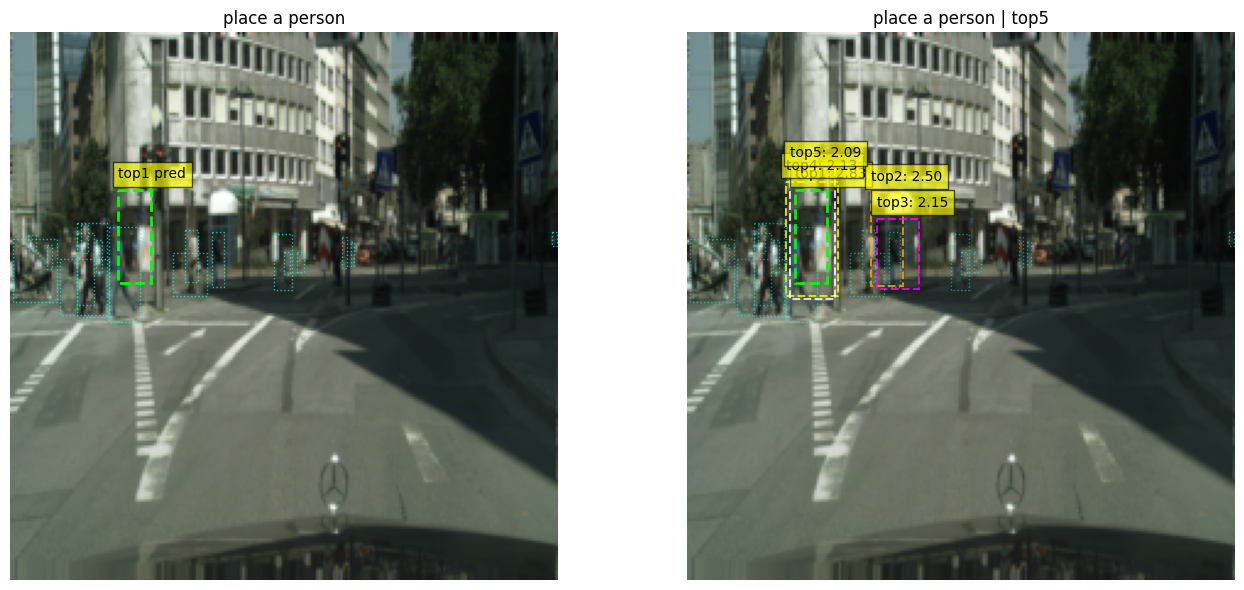

running image 1/6 | prompt = place a car
saved: raw_cityscapes_tests_supportsurface_hard\frankfurt_000001_007973_place_a_car.png


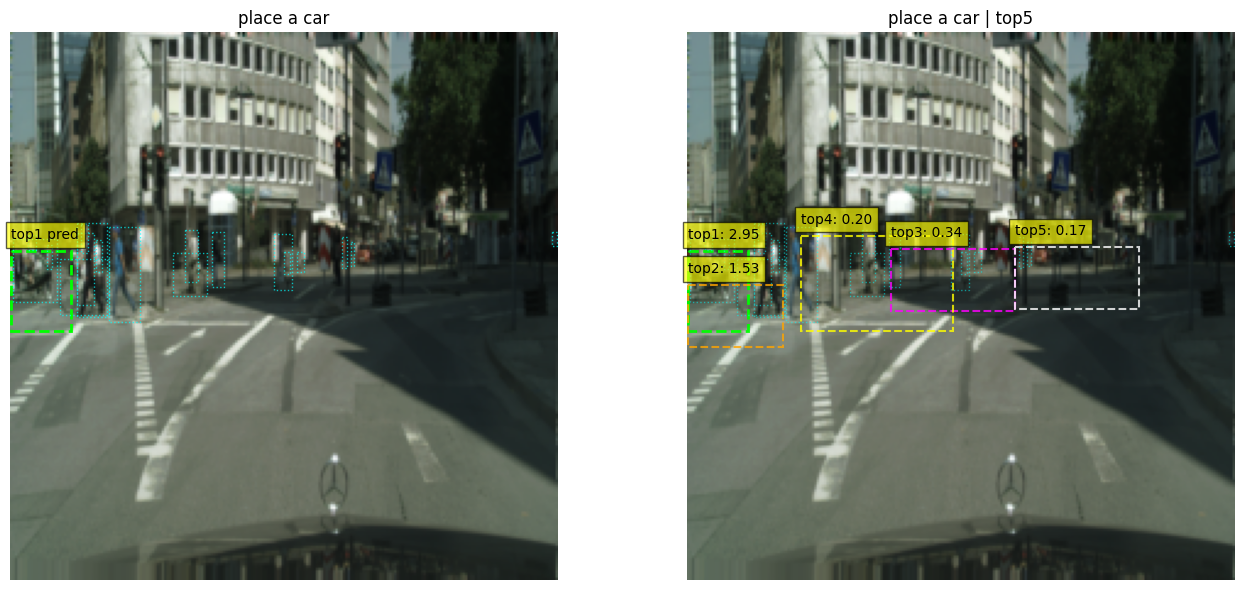

running image 2/6 | prompt = place a person
saved: raw_cityscapes_tests_supportsurface_hard\lindau_000024_000019_place_a_person.png


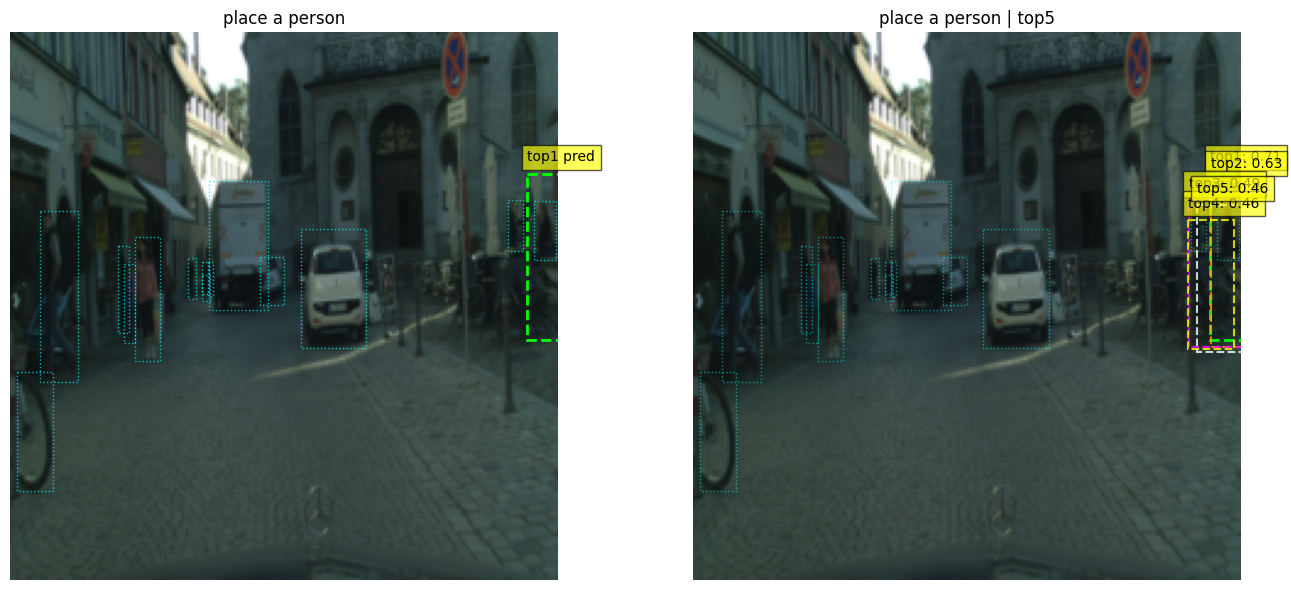

running image 2/6 | prompt = place a car
saved: raw_cityscapes_tests_supportsurface_hard\lindau_000024_000019_place_a_car.png


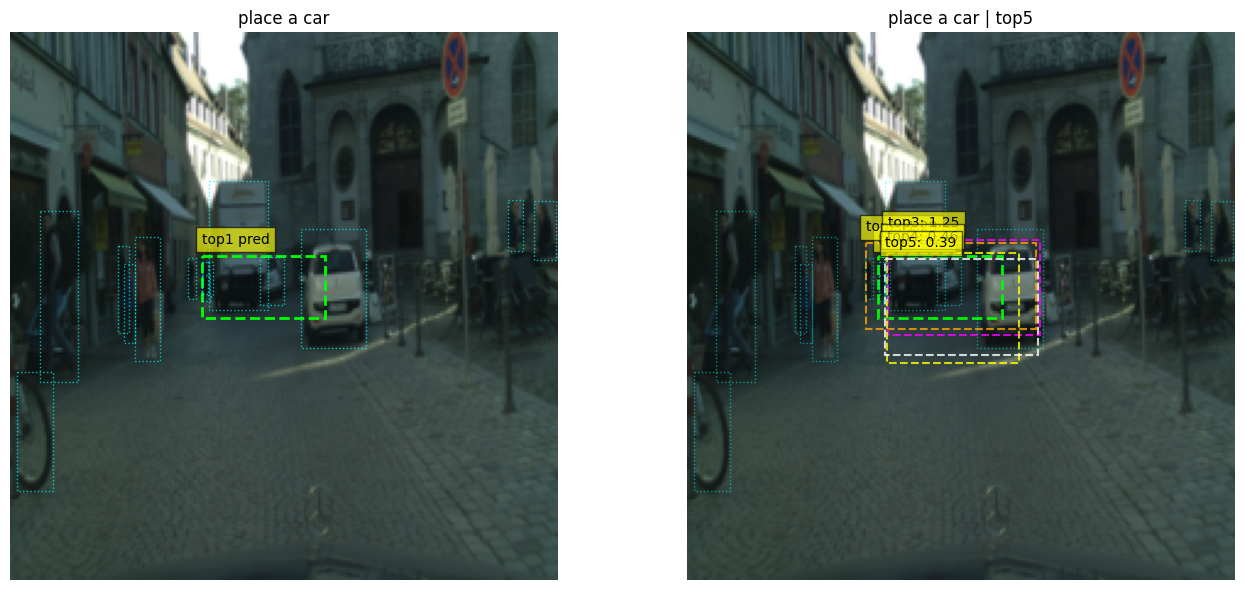

running image 3/6 | prompt = place a person
saved: raw_cityscapes_tests_supportsurface_hard\munster_000107_000019_place_a_person.png


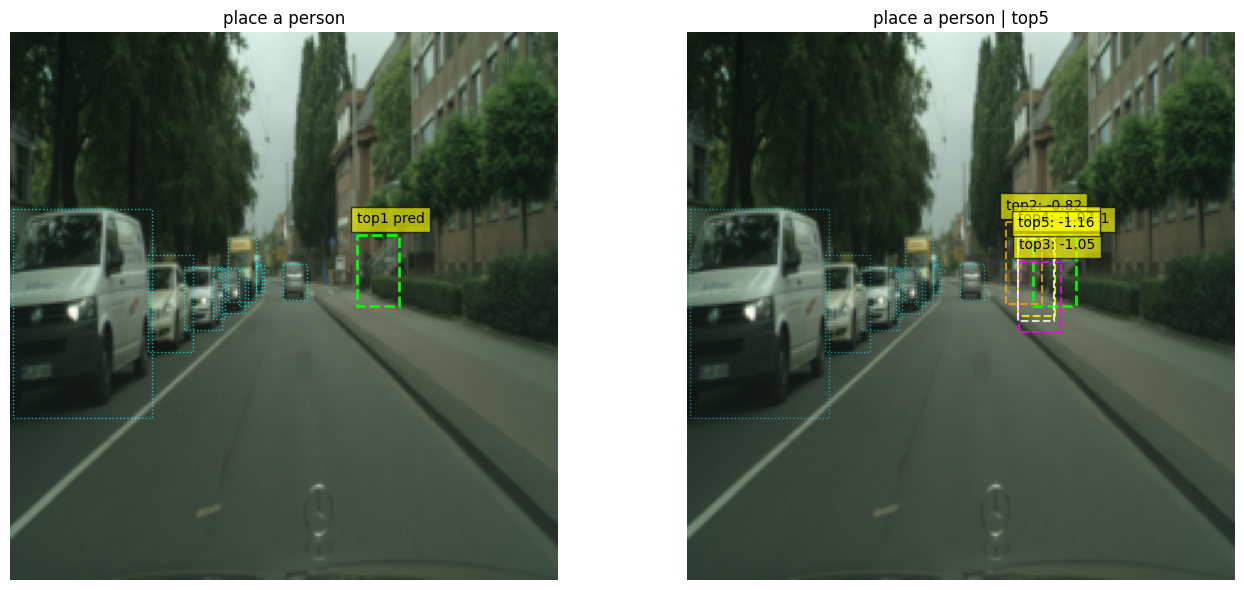

running image 3/6 | prompt = place a car
saved: raw_cityscapes_tests_supportsurface_hard\munster_000107_000019_place_a_car.png


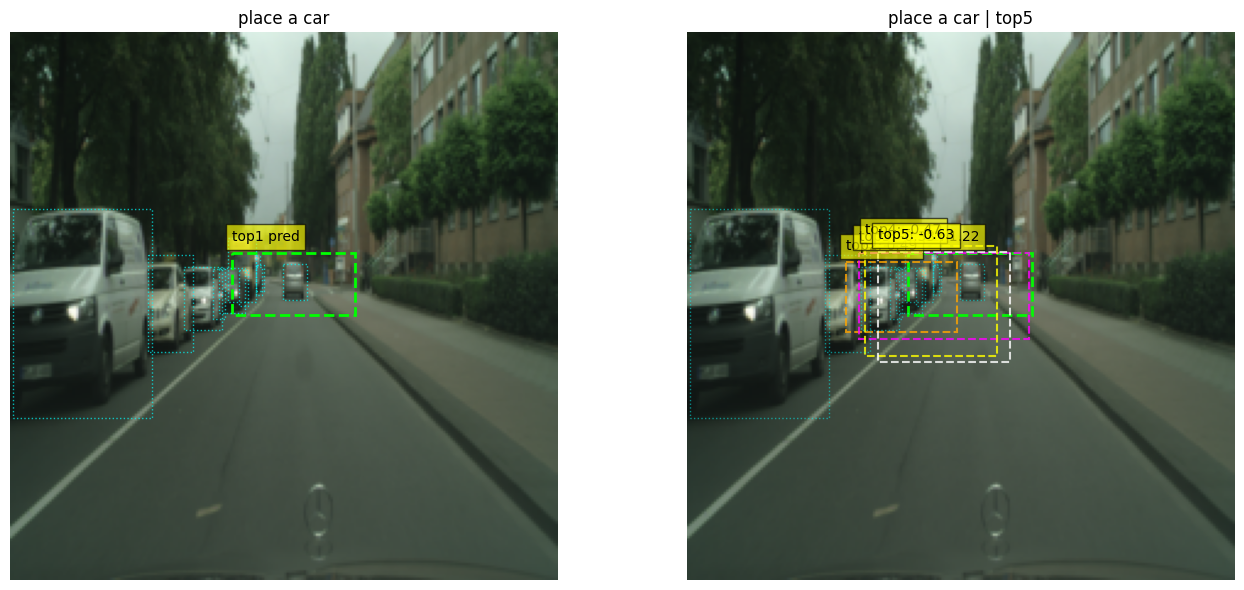

running image 4/6 | prompt = place a person
saved: raw_cityscapes_tests_supportsurface_hard\munster_000084_000019_place_a_person.png


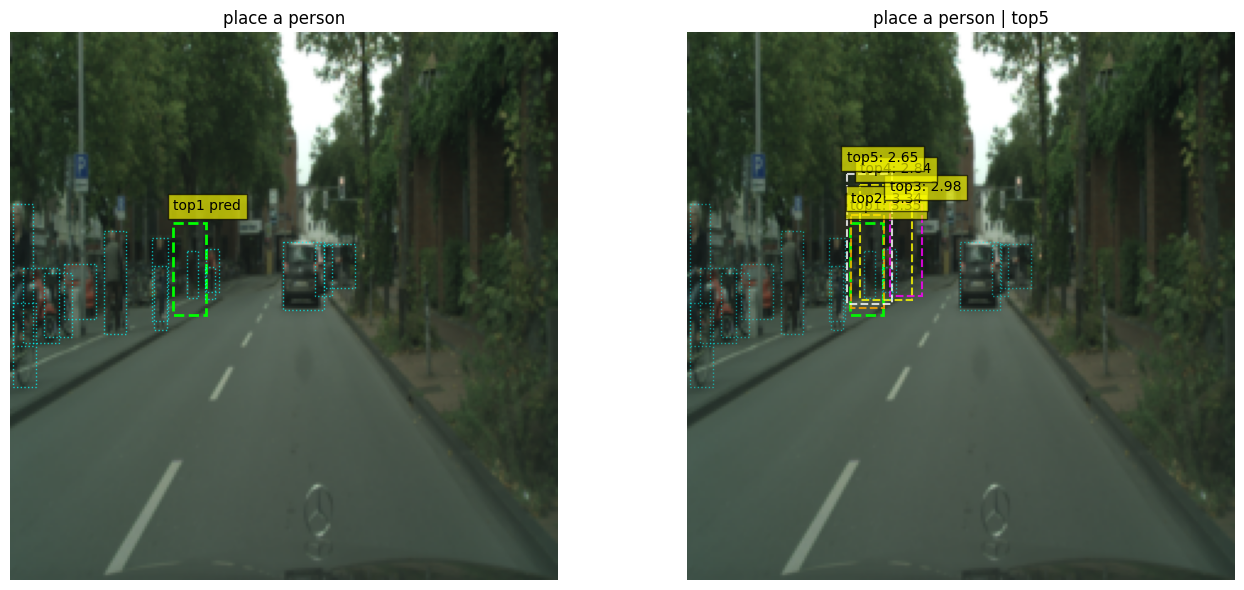

running image 4/6 | prompt = place a car
saved: raw_cityscapes_tests_supportsurface_hard\munster_000084_000019_place_a_car.png


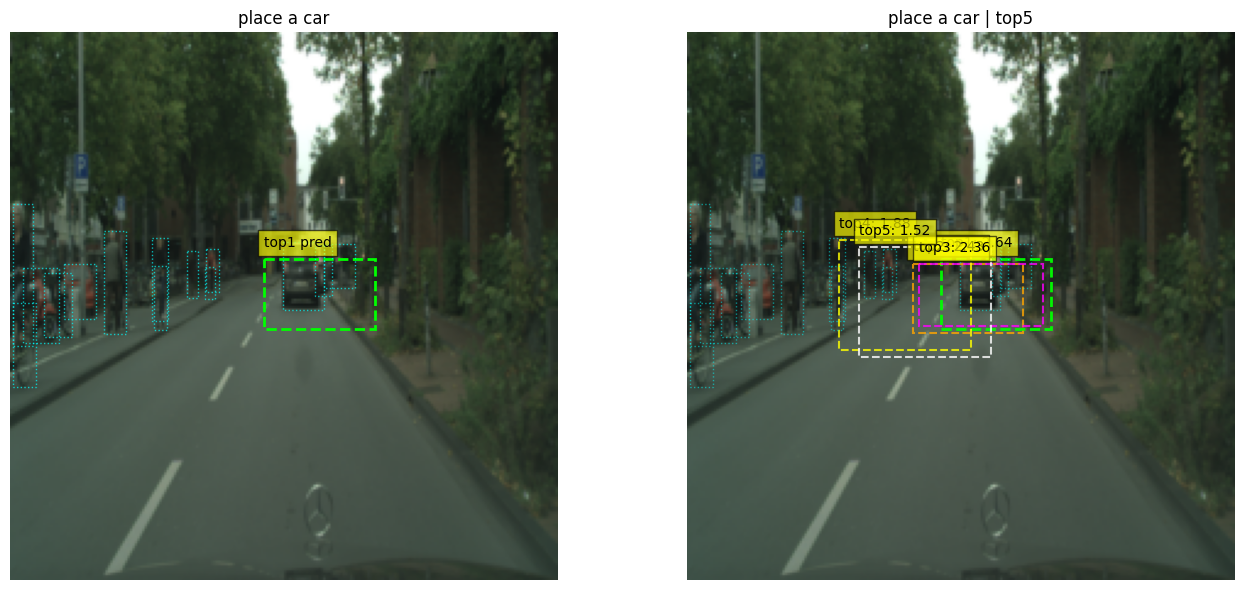

running image 5/6 | prompt = place a person
saved: raw_cityscapes_tests_supportsurface_hard\munster_000065_000019_place_a_person.png


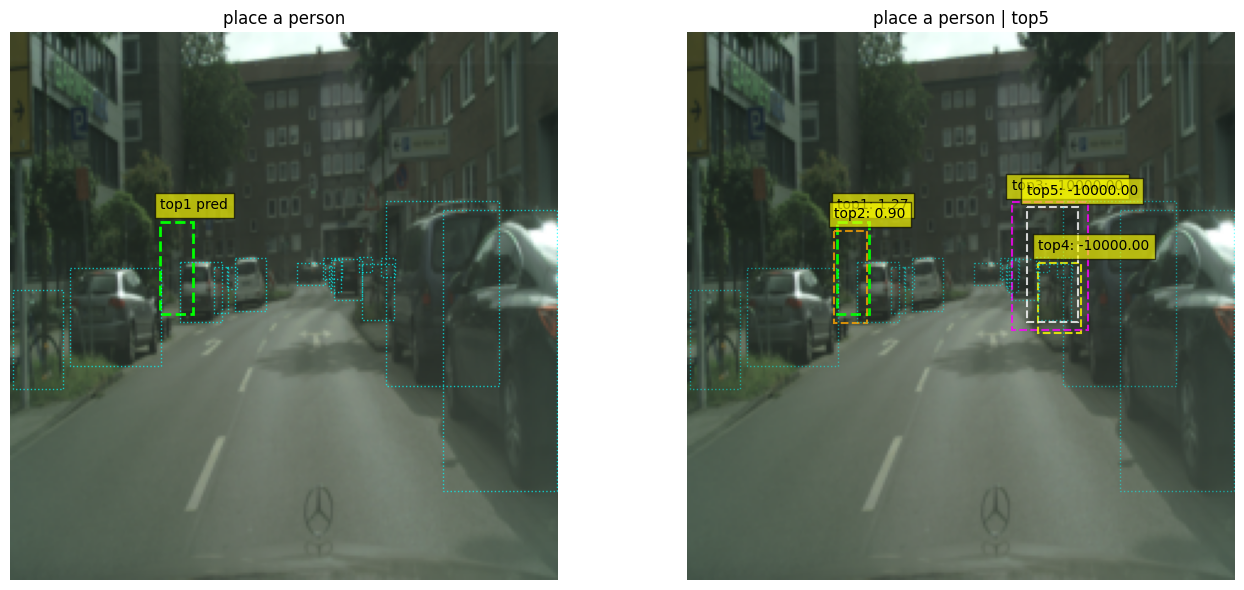

running image 5/6 | prompt = place a car
saved: raw_cityscapes_tests_supportsurface_hard\munster_000065_000019_place_a_car.png


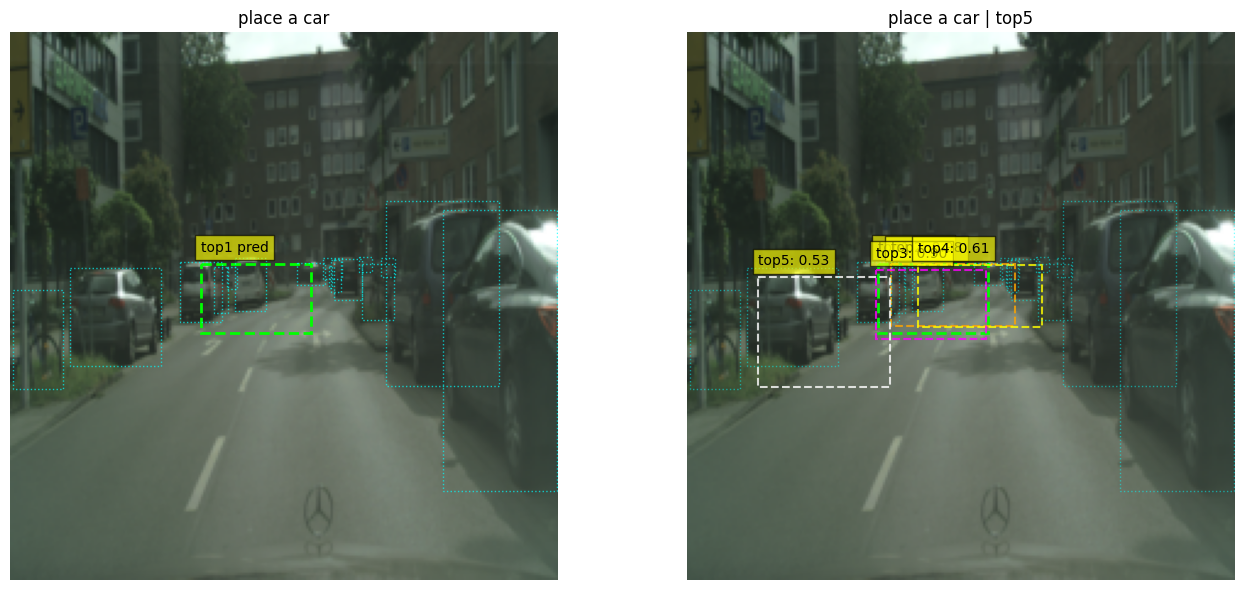

running image 6/6 | prompt = place a person
saved: raw_cityscapes_tests_supportsurface_hard\frankfurt_000000_013382_place_a_person.png


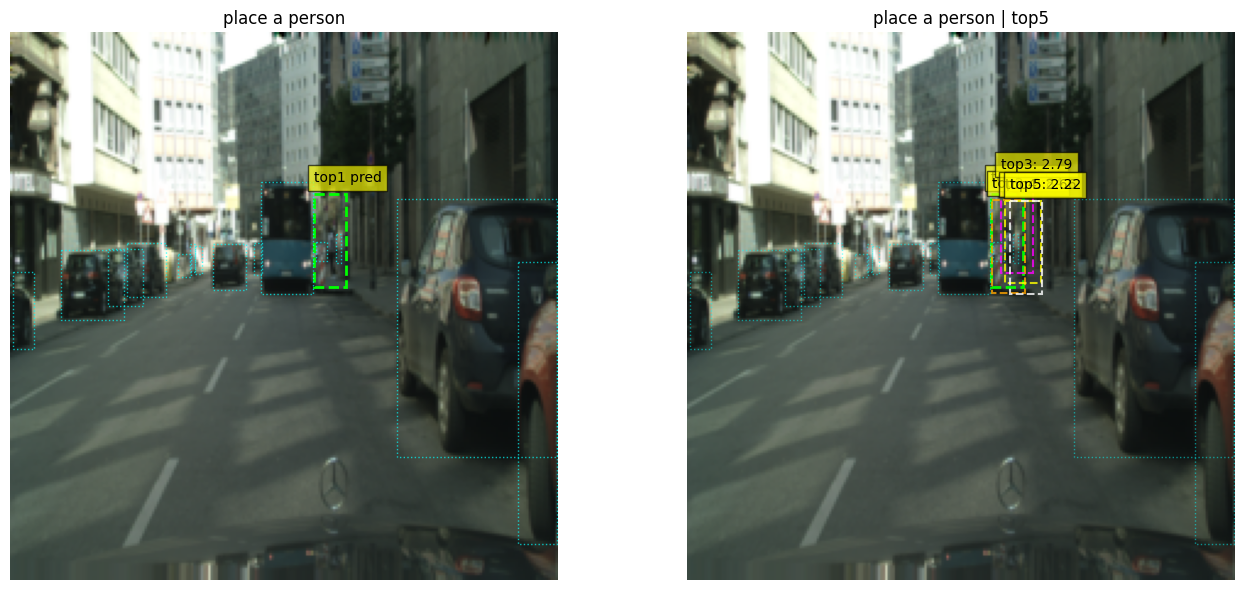

running image 6/6 | prompt = place a car
saved: raw_cityscapes_tests_supportsurface_hard\frankfurt_000000_013382_place_a_car.png


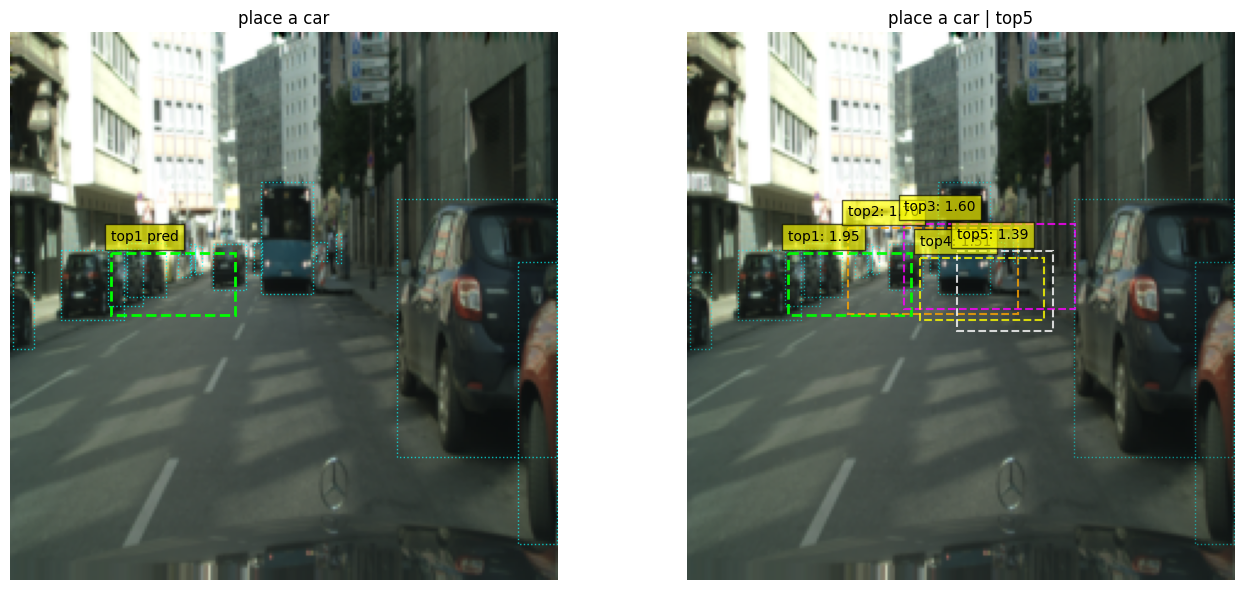

done, total results = 12


In [59]:
all_results_ss_hard = []

for img_idx, raw_img_path in enumerate(sampled_images):
    for prompt in TEST_PROMPTS:
        print(f"running image {img_idx + 1}/{len(sampled_images)} | prompt = {prompt}")

        result_ss_hard = run_supportsurface_hard_model_on_raw_cityscapes_image(
            raw_img_path=raw_img_path,
            prompt=prompt,
            model_ss=model_ss,
            scene_class_vocab=scene_class_vocab,
            cityscapes_root=CITYSCAPES_ROOT,
            min_area=256,
            image_size=224,
            num_candidates=256,
            support_ratio=0.95,
            seed=42 + img_idx,
            device=device,
        )

        stem = Path(raw_img_path).stem.replace("_leftImg8bit", "")
        prompt_tag = prompt.replace(" ", "_")
        save_path = RAW_TEST_OUT_DIR_SS_HARD / f"{stem}_{prompt_tag}.png"

        visualize_supportsurface_raw_result(result_ss_hard, save_path=save_path)
        all_results_ss_hard.append(result_ss_hard)

print("done, total results =", len(all_results_ss_hard))